# Laboratory work 3

## Modeling a Bayesian classifier for Gaussian random vectors

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
from collections.abc import Callable

class Bayesian_classifier:
    def __init__(self, N: int, L:int):
        self.N = N
        self.L = L
        self.a_priori_probabilities = []
        self.conditional_densities = []

    def gaussian_density(self, mu: np.ndarray, sigma: np.ndarray)->Callable:
        density = lambda x: (2 * np.pi) ** (-self.N/2) * np.linalg.det(sigma) ** (-1/2) \
            * np.exp(-(x - mu).T @ np.linalg.inv(sigma) @ (x - mu) / 2)
        return density
    
    def set_probability_characteristics(self, apriory_probabilities: list[float],
                                         conditional_densities: list[Callable])->None:
        self.a_priori_probabilities = apriory_probabilities
        self.conditional_densities = conditional_densities

    def bayesian_classifier(self, x: np.ndarray)->list[float]:
        a_posteriori_probabilities: list[float] = []
        f: list[float] = []
        for i in range(self.L):
            f.append(self.a_priori_probabilities[i] * self.conditional_densities[i](x))

        summ = sum(f)
        for i in range(self.L):
            a_posteriori_probabilities.append(f[i] / summ)

        return a_posteriori_probabilities

### 1. All probability characteristics are known.

$N=2, L=2, \pi_1 = \pi_2 = 0.5, M_i=M_i'=20, i=1,2, K=20$

$\mu_1 = (-1, -1)^T,\ \mu_2=(1, 1)^T$

a. $\Sigma_1=\Sigma_2=\begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$

In [10]:
mu_1 = np.array([-1, -1])
mu_2 = np.array([1, 1])
sigma = np.array([[1, 0], [0, 1]])
a_priori = [0.5, 0.5]

In [13]:
bc = Bayesian_classifier(2, 2)
density_1 = bc.gaussian_density(mu_1, sigma)
density_2 = bc.gaussian_density(mu_2, sigma)

bc.set_probability_characteristics(a_priori, [density_1, density_2])
bc.bayesian_classifier(np.array([-2, -2]))

[np.float64(0.9996646498695335), np.float64(0.0003353501304664781)]

In [5]:
from scipy.stats import chi2
from matplotlib.patches import Ellipse

def plot_ellipsoid(ax, mu: np.ndarray, sigma: np.ndarray, color: str, alpha=0.95):
    chi2_val = chi2.ppf(alpha, df=2)
    eigvals, eigvecs = np.linalg.eigh(sigma)
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width = 2 * np.sqrt(eigvals[0] * chi2_val)   # 2 * радиус (полная ширина)
    height = 2 * np.sqrt(eigvals[1] * chi2_val)
    
    # Создаём эллипс
    ell = Ellipse(xy=mu.tolist(), width=width, height=height, angle=angle, color=color)
    ax.add_patch(ell)

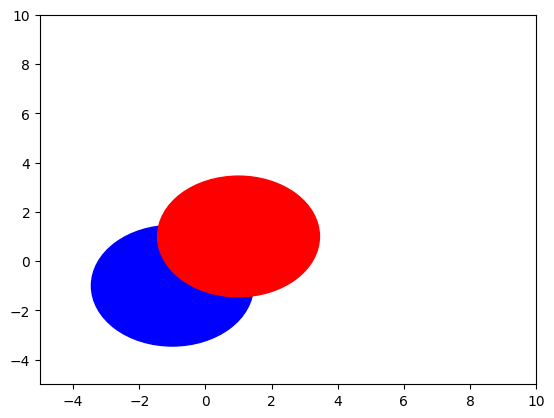

In [6]:
fig, ax = plt.subplots()
plot_ellipsoid(ax, mu_1, sigma, 'blue')
plot_ellipsoid(ax, mu_2, sigma, 'red')
plt.xlim(-5, 10)
plt.ylim(-5, 10)
plt.show()

In [7]:
x = np.linspace(-2, 2, 100)
y = density_1(x)
plt.plot(x, y)
plt.show()

ValueError: operands could not be broadcast together with shapes (100,) (2,) 